# Modern Census Maps & Data Visualization

This notebook demonstrates how to fetch US Census data using the `census` library and visualize it using modern mapping tools like Folium and Plotly Express.

## Setup
First, we import the necessary libraries.

In [1]:
import pandas as pd
import geopandas as gpd
from census import Census
from us import states
import folium
import plotly.express as px
import matplotlib.pyplot as plt
import mapclassify

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

## 1. Census API Connection

You will need a Census API key. You can get one here: https://api.census.gov/data/key_signup.html
Paste your key below. If you don't have one, some endpoints might still work but it's recommended to have one.

In [2]:
# REPLACE WITH YOUR API KEY
CENSUS_API_KEY = "942e0a44c121ca03ced84b727df9b004f1f1367d"

c = Census(CENSUS_API_KEY)

## 2. Fetching Census Data

We will fetch the Median Household Income (Variable: `B19013_001E`) for all states from the 2021 ACS 5-Year Estimates.

Common Variables used:
- B19013_001E: Median Household Income
- B01003_001E: Total Population

In [3]:
VARIABLE_CODE = "B19013_001E"
VARIABLE_NAME = "Median_Income"

# Fetch data for all states
census_data = c.acs5.get(("NAME", VARIABLE_CODE), {'for': 'state:*'})

# Convert to DataFrame
df_census = pd.DataFrame(census_data)

# Rename columns
df_census = df_census.rename(columns={VARIABLE_CODE: VARIABLE_NAME, "state": "STATEFP"})

# Convert income to numeric
df_census[VARIABLE_NAME] = pd.to_numeric(df_census[VARIABLE_NAME])

# Display first few rows
df_census.head()

,NAME,Median_Income,STATEFP
0,Alabama,62027.0,01
1,Alaska,89336.0,02
2,Arizona,76872.0,04
3,Arkansas,58773.0,05
4,California,96334.0,06


## 3. Fetching Geometry Data

We need the shapefiles for US states to map the data. We can use the generic US states shapefile available online directly via GeoPandas.

In [4]:
# Load US States Geometry (low resolution for faster rendering)
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"
gdf_states = gpd.read_file(url)

# Ensure STATEFP matches for merging
gdf_states = gdf_states.merge(df_census, on="STATEFP", how="left")

# Rename 'NAME_x' back to 'NAME' if it exists (result of merge collision)
if 'NAME_x' in gdf_states.columns:
    gdf_states = gdf_states.rename(columns={'NAME_x': 'NAME'})

# Filter out territories for a cleaner map (optional, keep only mainland + AK/HI)
# Keep only states that have income data
gdf_states = gdf_states.dropna(subset=[VARIABLE_NAME])

# Reproject to Web Mercator for interactive maps
gdf_states = gdf_states.to_crs(epsg=4326)

gdf_states.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry,NAME_y,Median_Income
0,22,01629543,0400000US22,22,LA,Louisiana,00,111915258185,23736382213,"POLYGON ((-94.04305 32.69303, -94.04303 32.797...",Louisiana,60023.0
1,02,01785533,0400000US02,02,AK,Alaska,00,1478942847588,245378425142,"MULTIPOLYGON (((179.48132 51.97531, 179.58286 ...",Alaska,89336.0
2,24,01714934,0400000US24,24,MD,Maryland,00,25151992308,6979074857,"MULTIPOLYGON (((-76.04621 38.02553, -76.00734 ...",Maryland,101652.0
3,55,01779806,0400000US55,55,WI,Wisconsin,00,140292321657,29343646672,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ...",Wisconsin,75670.0
4,12,00294478,0400000US12,12,FL,Florida,00,138961722096,45972570361,"MULTIPOLYGON (((-81.81169 24.56874, -81.75127 ...",Florida,71711.0


## 4. Visualization 1: Interactive Folium Map

A classic interactive map using Leaflet.js via Folium. Good for detailed exploration.

In [6]:
m = folium.Map(location=[37.8, -96], zoom_start=4)

folium.Choropleth(
    geo_data=gdf_states,
    name="choropleth",
    data=gdf_states,
    columns=["NAME", "Median_Income"],
    key_on="feature.properties.NAME",
    fill_color="YlGn",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Median Household Income ($)"
).add_to(m)

folium.LayerControl().add_to(m)

# Save to HTML and display via IFrame to bypass Notebook Trust issues in VS Code
map_file = "census_map.html"
m.save(map_file)

from IPython.display import IFrame
IFrame(map_file, width="100%", height=600)

## 5. Visualization 2: Modern Plotly Express Map

Plotly Express offers a very modern, responsive, and easy-to-use interface. This map includes hover details out-of-the-box.

In [11]:
fig = px.choropleth(
    gdf_states,
    geojson=gdf_states.geometry,
    locations=gdf_states.index,
    color=VARIABLE_NAME,
    hover_name="NAME",
    color_continuous_scale="Viridis",
    
    title="US Median Household Income by State (2021)"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})

fig.show()

## 6. Visualization 3: Styled Static Map (Matplotlib)

Sometimes a clean, high-quality static image is what you need for reports.

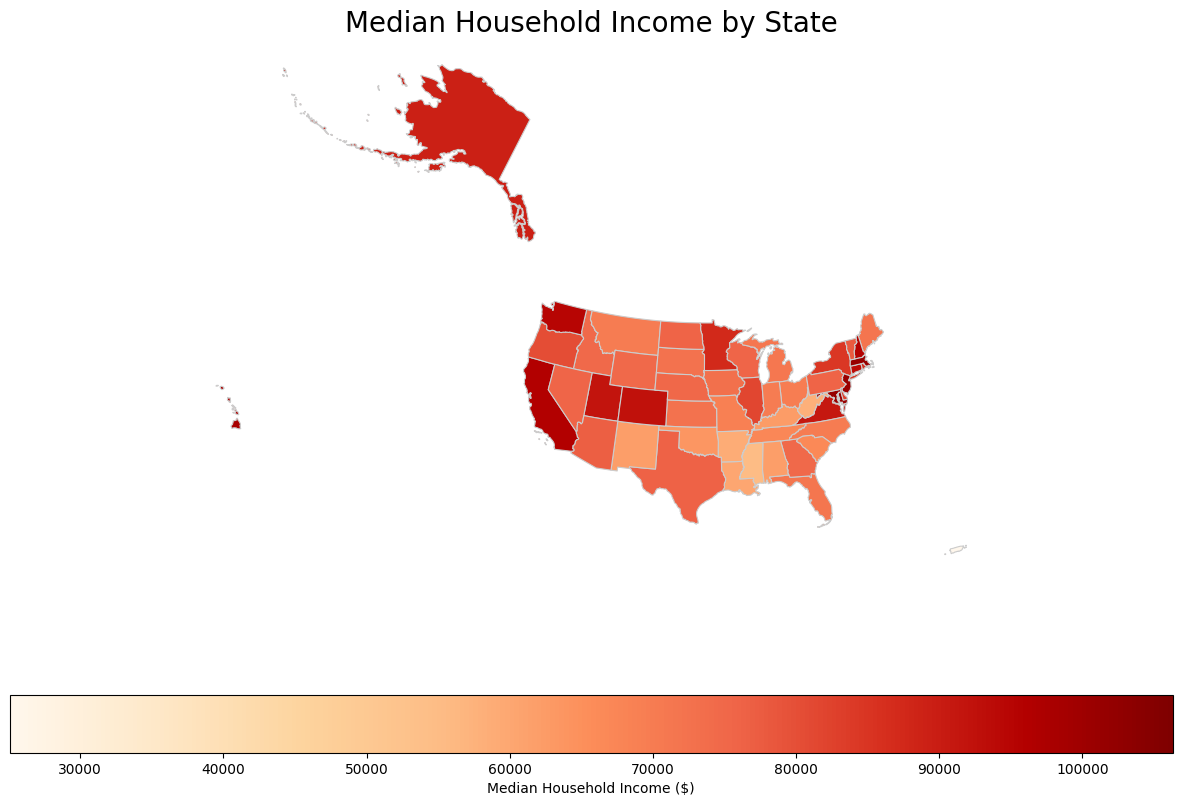

In [ ]:
# Set coordinate reference system to Albers Equal Area for better US projection
gdf_albers = gdf_states.to_crs(epsg=5070)

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf_albers.plot(
    column=VARIABLE_NAME,
    cmap='OrRd',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Median Household Income ($)", 'orientation': "horizontal"}
)

ax.axis('off')
plt.title("Median Household Income by State", fontsize=20)
plt.show()